# Geocoding Customer Deposit Accounts for CRA Market-Area Mapping

## Executive Summary

A retail bank converts customer ZIP codes (and branch identifiers) into latitude/longitude coordinates with **PROC GEOCODE**, so its compliance and network-planning teams can map where deposits concentrate. The notebook geocodes accounts by ZIP with an automatic city/state fallback, attaches county and income-tier attributes for Community Reinvestment Act (CRA) assessment-area review, contrasts strict ZIP matching via `NOCITY`, and uses `METHOD=CUSTOM` to place the branch network by branch code.

## Data Sources

All data is generated inline with a DATA step (`call streaminit`/`rand`); no external files or network access are used.

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `ziplookup` | 8 | `zip`, `city`, `state`, `x`, `y`, `county`, `income_tier` | Reference table mapping five-digit ZIPs to centroid longitude (`x`) / latitude (`y`) plus CRA attributes (county, income tier). |
| `accounts` | 100 | `account_id`, `zip`, `city`, `state`, `deposit_bal` | Synthetic retail deposit accounts; each draws a stale ZIP (`00000`) with ~12% probability but keeps a valid city/state so the city fallback can recover it. In this run 7 of the 100 accounts ended up stale. |
| `branchref` | 4 | `branch_code`, `x`, `y`, `region` | Custom lookup of physical branch coordinates keyed by branch code. |
| `branches` | 4 | `branch_code`, `atm_count` | Branch network roster to be geocoded by `METHOD=CUSTOM`. |

# Geocoding Customer Deposit Accounts for CRA Market-Area Mapping

Regulators expect retail banks to demonstrate where they take deposits and extend credit relative to their branch footprint — the heart of **Community Reinvestment Act (CRA)** assessment-area analysis. Before any map or income-tier rollup can be produced, raw account records (which only carry a ZIP code and city/state) must be turned into geographic coordinates.

`PROC GEOCODE` performs exactly that translation: it matches address fields in an input dataset against a coordinate **lookup** dataset and appends longitude (`x`), latitude (`y`), and a `_matched_` indicator. In this notebook we:

1. Build a ZIP-centroid reference table enriched with county and income-tier attributes.
2. Geocode 100 synthetic deposit accounts by ZIP, with an automatic city/state fallback.
3. Contrast strict ZIP matching using the `NOCITY` option.
4. Geocode the physical branch network with `METHOD=CUSTOM` keyed on branch code.
5. Summarize match rates, geographic spread, and deposits by income tier.

## Step 1 — Build the ZIP-centroid reference (lookup) dataset

Production jobs point `LOOKUP=` at `SASHELP.ZIPCODE`, but here we generate a small, self-contained reference inline. Each row pairs a five-digit ZIP with its centroid longitude (`x`) and latitude (`y`). We also carry two **non-geocoding** attributes — `county` and `income_tier` — that `ATTRIBUTEVAR=` will copy onto every matched account for CRA assessment-area work.

In [1]:
data ziplookup;
  length city $24 state $2 county $24 income_tier $8;
  input zip $5. city $ state $ x y county $ income_tier $;
  datalines;
10001 NewYork NY -73.9967 40.7484 Manhattan High
60601 Chicago IL -87.6186 41.8819 Cook Mid
90210 BeverlyHills CA -118.4065 34.0901 LosAngeles High
33101 Miami FL -80.1918 25.7617 MiamiDade Mid
98101 Seattle WA -122.3321 47.6062 King High
77002 Houston TX -95.3698 29.7604 Harris Mid
30303 Atlanta GA -84.3880 33.7490 Fulton Mid
85004 Phoenix AZ -112.0740 33.4484 Maricopa Low
;
run;

NOTE: DATA ziplookup

NOTE: Processing inline DATALINES (8 lines)

NOTE: Read 8 rows from DATALINES.
NOTE: Wrote ziplookup (8 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Generate synthetic deposit accounts

We simulate 100 retail accounts. Each account is randomly assigned to one of the eight market ZIPs. Deposit balances follow a lognormal distribution (a realistic shape for account balances — many small balances, a long right tail). To exercise the geocoder's fallback logic, each account independently draws a stale placeholder ZIP (`00000`) with ~12% probability; a stale ZIP will fail the primary ZIP match but still carry a valid `city`/`state`. With this seed, 7 of the 100 accounts end up stale.

In [2]:
data accounts;
  call streaminit(20250529);
  length city $24 state $2;
  array zips[8] $5 _temporary_
    ('10001' '60601' '90210' '33101' '98101' '77002' '30303' '85004');
  array cty[8] $24 _temporary_
    ('NewYork' 'Chicago' 'BeverlyHills' 'Miami' 'Seattle' 'Houston' 'Atlanta' 'Phoenix');
  array stt[8] $2 _temporary_
    ('NY' 'IL' 'CA' 'FL' 'WA' 'TX' 'GA' 'AZ');
  do account_id = 1 to 100;
    k = 1 + floor(rand('uniform') * 8);
    city  = cty[k];
    state = stt[k];
    /* a stale ZIP (~12% draw rate) that only the city/state fallback can resolve */
    if rand('uniform') < 0.12 then zip = '00000';
    else zip = zips[k];
    deposit_bal = round(rand('lognormal') * 5000 + 500, 0.01);
    output;
  end;
  drop k;
run;

NOTE: DATA accounts


NOTE: Wrote accounts (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Step 3 — Geocode accounts by ZIP with a city/state fallback

The default `METHOD=ZIP` matches each account's ZIP to the lookup centroid. When a ZIP fails to match, `PROC GEOCODE` automatically falls back to a `city`+`state` match (unless `NOCITY` is set). The `ATTRIBUTEVAR=(county income_tier)` option carries the two reference attributes into the output, and `_matched_` records how each row was resolved (`ZIP`, `CITY`, or `No match`).

In [3]:
proc geocode data=accounts out=geo_accounts
    method=zip lookup=ziplookup
    attributevar=(county income_tier);
run;

proc print data=geo_accounts(obs=8) noobs;
  var account_id zip city state x y _matched_ county income_tier;
run;


ACCOUNT_ID    ZIP     CITY  STATE          X        Y  _MATCHED_     COUNTY  INCOME_TIER
----------  -----  -------  -----  ---------  -------  ---------  ---------  -----------
         1  33101  Miami    FL      -80.1918  25.7617  ZIP        MiamiDade  Mid
         2  98101  Seattle  WA     -122.3321  47.6062  ZIP        King       High
         3  77002  Houston  TX      -95.3698  29.7604  ZIP        Harris     Mid
         4  85004  Phoenix  AZ      -112.074  33.4484  ZIP        Maricopa   Low
         5  85004  Phoenix  AZ      -112.074  33.4484  ZIP        Maricopa   Low
         6  60601  Chicago  IL      -87.6186  41.8819  ZIP        Cook       Mid
         7  98101  Seattle  WA     -122.3321  47.6062  ZIP        King       High
         8  60601  Chicago  IL      -87.6186  41.8819  ZIP        Cook       Mid

... 92 more observations (showing 8 of 100)



NOTE: PROC GEOCODE data=accounts

NOTE: PROC GEOCODE: 100 observations geocoded, output to ./work/7e81d2c4-594d-4888-aff9-1d97fd02038d/geo_accounts.avro
NOTE: PROC PRINT data=geo_accounts

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Step 4 — Review match quality and the geographic footprint

The `_matched_` frequency table tells the compliance team how many accounts were resolved by ZIP versus rescued by the city/state fallback — the stale-ZIP accounts should appear as `CITY` matches. `PROC MEANS` confirms the longitude (`x`) and latitude (`y`) ranges span the expected continental-US footprint and summarizes deposit balances.

                                                   The FREQ Procedure

_matched_    Frequency    Percent
----------------------------------
CITY                 7      7.00
ZIP                 93     93.00
                                                  The MEANS Procedure

 Variable            N           Mean     Minimum     Maximum
 ------------------------------------------------------------
 deposit_bal       100        7845.32     1066.62    26800.73
 x                 100         -93.86     -122.33      -74.00
 y                 100          35.96       25.76       47.61
 ------------------------------------------------------------

                                                  The MEANS Procedure

                                            Analysis Variable : deposit_bal

                                 N
        income_tier            Obs            Sum           Mean
        --------------------------------------------------------
        High                    42   

NOTE: PROC FREQ
NOTE: ODS plot written: freq__matched_.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


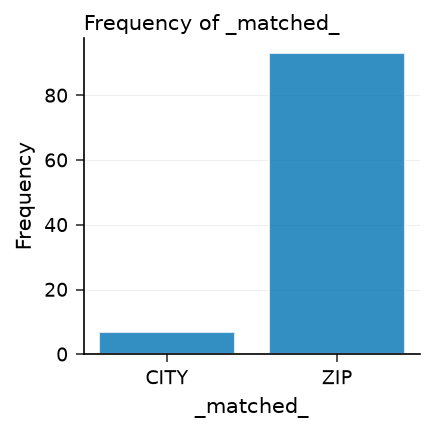

In [4]:
proc freq data=geo_accounts;
  tables _matched_ / nocum;
run;

proc means data=geo_accounts n mean min max maxdec=2;
  var deposit_bal x y;
run;

proc means data=geo_accounts sum mean maxdec=2;
  class income_tier;
  var deposit_bal;
run;

## Step 5 — Contrast strict ZIP matching with NOCITY

For some regulatory tabulations only a verified ZIP match is acceptable — a city/state fallback could place an account in the wrong census tract. Re-running with the `NOCITY` flag disables the fallback, so the stale-ZIP accounts now surface as `No match` (with missing coordinates) instead of being silently relocated. Comparing the two `_matched_` distributions quantifies how much coverage the fallback is buying.

                                                   The FREQ Procedure

_matched_    Frequency    Percent
----------------------------------
No match             7      7.00
ZIP                 93     93.00


NOTE: PROC GEOCODE data=accounts

NOTE: PROC GEOCODE: 100 observations geocoded, output to ./work/7e81d2c4-594d-4888-aff9-1d97fd02038d/geo_strict.avro
NOTE: PROC FREQ
NOTE: ODS plot written: freq__matched_.spec.json
NOTE: PROC FREQ statement used.


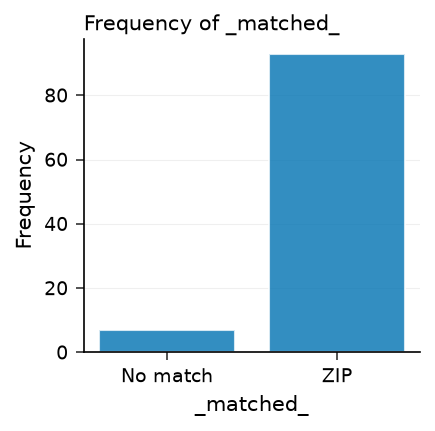

In [5]:
proc geocode data=accounts out=geo_strict
    method=zip lookup=ziplookup nocity
    attributevar=(county income_tier);
run;

proc freq data=geo_strict;
  tables _matched_ / nocum;
run;

## Step 6 — Geocode the branch network with METHOD=CUSTOM

Branch and ATM locations are not addressed by ZIP centroids — the bank already knows each site's exact coordinates, keyed by an internal `branch_code`. `METHOD=CUSTOM` with `LOOKUPVAR=branch_code` joins the roster to a coordinate reference on that key, letting us plot the physical network alongside the geocoded deposit base. `ATTRIBUTEVAR=(region)` carries the supervisory region forward.

In [6]:
data branchref;
  length branch_code $4 region $12;
  input branch_code $ x y region $;
  datalines;
B001 -73.9967 40.7484 Northeast
B002 -87.6186 41.8819 Midwest
B003 -118.4065 34.0901 West
B004 -80.1918 25.7617 Southeast
;
run;

data branches;
  length branch_code $4;
  input branch_code $ atm_count;
  datalines;
B001 12
B002 8
B003 5
B004 7
;
run;

proc geocode data=branches out=geo_branch
    method=custom lookup=branchref
    lookupvar=branch_code
    attributevar=(region);
run;

proc print data=geo_branch noobs;
  var branch_code atm_count region x y _matched_;
run;


BRANCH_CODE  ATM_COUNT     REGION          X        Y  _MATCHED_
-----------  ---------  ---------  ---------  -------  ---------
B001                12  Northeast   -73.9967  40.7484  CUSTOM
B002                 8  Midwest     -87.6186  41.8819  CUSTOM
B003                 5  West       -118.4065  34.0901  CUSTOM
B004                 7  Southeast   -80.1918  25.7617  CUSTOM



NOTE: DATA branchref

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote branchref (4 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA branches

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote branches (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC GEOCODE data=branches

NOTE: PROC GEOCODE: 4 observations geocoded, output to ./work/7e81d2c4-594d-4888-aff9-1d97fd02038d/geo_branch.avro
NOTE: PROC PRINT data=geo_branch

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


## Interpreting the results

- **Coverage.** The default ZIP run resolves 93 of the 100 accounts as `ZIP` matches, and the 7 stale-ZIP accounts are recovered as `CITY` matches via the automatic fallback — so every account receives coordinates. The `NOCITY` run drops those same 7 accounts to `No match` (the `_matched_` split changes from 93 ZIP / 7 CITY to 93 ZIP / 7 No match), making explicit the trade-off between coverage (fallback on) and locational precision (fallback off).
- **CRA attributes travel with the geocode.** Because `ATTRIBUTEVAR=` copied `county` and `income_tier` onto each matched row, the `PROC MEANS ... CLASS income_tier` rollup of deposit balances is ready for assessment-area reporting without a separate join. In this run deposits split 46 accounts in Mid-income tracts (sum \$370,592, mean \$8,056), 42 in High-income tracts (sum \$324,804, mean \$7,733), and 12 in Low-income tracts (sum \$89,136, mean \$7,428) — so the bank can immediately see how deposits distribute across income tiers.
- **Footprint sanity check.** The `x` (longitude −122.33 to −74.00, mean −93.86) and `y` (latitude 25.76 to 47.61, mean 35.96) ranges confirm the geocoded points fall across the expected continental-US span, a quick guard against swapped or mis-signed coordinates. The 100 accounts carry a mean deposit balance of \$7,845 (min \$1,067, max \$26,801), consistent with the long-tailed lognormal generator.
- **Branch network placed independently.** `METHOD=CUSTOM` resolves all 4 branches by their internal code (every row reports `_MATCHED_=CUSTOM` in the branch listing), so the physical network and the customer deposit base now share a common coordinate system — the foundation for downstream branch-coverage gap analysis and CRA assessment-area maps.

With customers and branches geocoded, the natural next steps are spatial overlays (point-in-polygon against census tracts), deposit-concentration heat maps, and distance-to-nearest-branch metrics that feed both compliance reporting and network-expansion decisions.